<a href="https://colab.research.google.com/github/hirenpatel1404/Assignment_13_Generative_AI_Essentials/blob/main/Assignment_13_Generative_AI_Essentials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the Hugging Face libraries we need.
# -q means "quiet" (less log spam). Run this once per Colab session.
!pip install -q transformers datasets accelerate
print("Libraries installed.")

Libraries installed.


In [ ]:
#imports + GPU check:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Check that Colab gave us a GPU. Fine-tuning on CPU would take hours.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if device == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU.")

Using device: cuda
GPU name: Tesla T4


###Instruction:
 The Pile is 800GB, so instead of downloading it I stream it — pull samples one at a time and stop once I have enough. I'll grab 2,000 text samples, which is enough to fine-tune on and light for Colab. I use the monology/pile-uncopyrighted mirror because the original EleutherAI host is offline.

#stream samples from The Pile:

In [ ]:
from datasets import load_dataset

# I stream The Pile instead of downloading all 800GB.
# streaming=True = pull data on demand, one sample at a time.
# I use a public mirror since the original Pile host is down.
print("Connecting to The Pile (streaming)...")
dataset = load_dataset(
    "monology/pile-uncopyrighted",
    split="train",
    streaming=True
)

# I pull the first 2000 text samples into a normal Python list.
# Each Pile entry is a dict like {"text": "...", "meta": {...}} — I keep the text.
num_samples = 2000
texts = []
for i, example in enumerate(dataset):
    if i >= num_samples:
        break
    texts.append(example["text"])

print(f"Collected {len(texts)} text samples from The Pile.")

Connecting to The Pile (streaming)...


README.md:   0%|          | 0.00/776 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Collected 2000 text samples from The Pile.


In [ ]:
# The Pile mixes many sources (books, web, code, academic papers, etc.).
# I look at the start of the first sample to see what real Pile text looks like.
print("Number of samples:", len(texts))
print("Characters in sample 0:", len(texts[0]))
print("\n--- First 500 characters of sample 0 ---\n")
print(texts[0][:500])

Number of samples: 2000
Characters in sample 0: 13274

--- First 500 characters of sample 0 ---

It is done, and submitted. You can play “Survival of the Tastiest” on Android, and on the web. Playing on the web works, but you have to simulate multi-touch for table moving and that can be a bit confusing.

There’s a lot I’d like to talk about. I’ll go through every topic, insted of making the typical what went right/wrong list.

Concept

Working over the theme was probably one of the hardest tasks I had to face.

Originally, I had an idea of what kind of game I wanted to develop, gameplay wis


**Outcome:** I successfully collected 2,000 text samples from The Pile.
Inspecting sample 0 (13,274 characters) showed an informal developer blog
post about a mobile game. This confirms The Pile is a **mix of many sources**
(web text, books, code, academic papers), so my model will learn a broad,
general English style rather than one specific author's voice.

#combine samples and save to a file

In [ ]:
# I join all 2000 samples into one text file, separated by blank lines.
train_path = "pile_train.txt"
with open(train_path, "w", encoding="utf-8") as f:
    for sample in texts:
        f.write(sample.strip() + "\n\n")



In [ ]:
# Quick check: how big is the file?
import os
size_mb = os.path.getsize(train_path) / (1024 * 1024)
print(f"Saved training text to {train_path}")
print(f"File size: {size_mb:.2f} MB")

Saved training text to pile_train.txt
File size: 10.33 MB


#load the GPT-2 tokenizer and see tokenization in action

In [ ]:
# I load GPT-2's tokenizer. It uses Byte-Pair Encoding (BPE) to split
# text into sub-word tokens, then maps each token to an ID number.
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

# GPT-2 has no padding token by default, so I reuse the end-of-text token.
tokenizer.pad_token = tokenizer.eos_token

# Demo: show how a sentence becomes tokens, then IDs.
sample_sentence = "Generative AI can create new content."
tokens = tokenizer.tokenize(sample_sentence)
ids = tokenizer.encode(sample_sentence)

print("Original text:", sample_sentence)
print("\nTokens (sub-words):", tokens)
print("\nToken IDs (numbers):", ids)
print("\nVocabulary size:", tokenizer.vocab_size)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Original text: Generative AI can create new content.

Tokens (sub-words): ['Gener', 'ative', 'ĠAI', 'Ġcan', 'Ġcreate', 'Ġnew', 'Ġcontent', '.']

Token IDs (numbers): [8645, 876, 9552, 460, 2251, 649, 2695, 13]

Vocabulary size: 50257


#Interpretation
The 2,000 Pile samples were combined into a single 10.33 MB training file — a solid amount of text for fine-tuning. The tokenizer demo shows tokenization working exactly as described in the Lesson 13 slides: the sentence "Generative AI can create new content." became 8 tokens. Notice that "Generative" split into two tokens — Gener + ative — because it's a longer/rarer word, while common words like "can", "new", and "content" stayed whole. The Ġ symbol marks a space before a word (so ĠAI = " AI"). Each token maps to an ID number (e.g. AI → 9552), and these IDs are what the model actually processes. GPT-2's full vocabulary is 50,257 tokens.

The one takeaway worth remembering: tokens ≠ words. 6 words became 8 tokens here — that's Byte-Pair Encoding breaking rare words into sub-word pieces so the model can handle any text with a fixed vocabulary.

#Build the training dataset

In [ ]:
from datasets import Dataset

# I turn my list of Pile texts into a Hugging Face Dataset object.
raw_dataset = Dataset.from_dict({"text": texts})

# I define how to tokenize each piece of text.
block_size = 128

def tokenize_function(examples):
    # Turn text into token IDs, cut/pad everything to block_size tokens.
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=block_size,
        padding="max_length",
    )

# Apply tokenization to all 2000 samples.
# batched=True processes many at once (faster).
# remove_columns drops the original text, keeping only the token IDs.
tokenized_dataset = raw_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)

print("Tokenization complete.")
print("Number of training samples:", len(tokenized_dataset))
print("Keys in each sample:", tokenized_dataset[0].keys())
print("Length of first sample's input_ids:", len(tokenized_dataset[0]["input_ids"]))

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization complete.
Number of training samples: 2000
Keys in each sample: dict_keys(['input_ids', 'attention_mask'])
Length of first sample's input_ids: 128


In [ ]:
from transformers import DataCollatorForLanguageModeling

# The collator batches samples for training.
# mlm=False because GPT-2 is a causal (left-to-right) model, not masked like BERT.
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)
print("Data collator ready.")

Data collator ready.


###Interpretation
The 2,000 Pile samples were successfully tokenized into training examples. Each sample now has two parts: input_ids (the text as token ID numbers) and attention_mask (which tells the model which tokens are real vs. padding). Every sample was standardized to exactly 128 tokens — longer texts were truncated, shorter ones padded — so the model receives uniform-sized inputs. The data collator is ready to batch these during training.

#Load GPT-2 and fine-tune

In [ ]:
from transformers import GPT2LMHeadModel

# I load the GPT-2 model (124M parameters) and move it to the GPU.
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.to(device)

print(f"Model loaded on {device}.")
print(f"Total parameters: {model.num_parameters():,}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded on cuda.
Total parameters: 124,439,808


In [ ]:
from transformers import Trainer, TrainingArguments

# Training settings.
training_args = TrainingArguments(
    output_dir="./gpt2-pile",
    overwrite_output_dir=True,
    num_train_epochs=1,             # 1 pass over the data (enough for a demo)
    per_device_train_batch_size=4,  # 4 samples at a time
    save_steps=500,
    save_total_limit=1,
    logging_steps=25,               # record loss every 25 steps for the graph
    fp16=True,                      # half-precision: faster + fits in T4 memory
    report_to="none",
)

# The Trainer ties together the model, data, and settings.
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_dataset,
)

print("Starting fine-tuning...")
trainer.train()
print("Fine-tuning complete.")

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'overwrite_output_dir'

In [ ]:
from transformers import Trainer, TrainingArguments

# Training settings. (Removed 'overwrite_output_dir' — not supported in this
# transformers version; the folder is overwritten by default anyway.)
training_args = TrainingArguments(
    output_dir="./gpt2-pile",
    num_train_epochs=1,             # 1 pass over the data (enough for a demo)
    per_device_train_batch_size=4,  # 4 samples at a time
    save_steps=500,
    save_total_limit=1,
    logging_steps=25,               # record loss every 25 steps for the graph
    fp16=True,                      # half-precision: faster + fits in T4 memory
    report_to="none",
)

# The Trainer ties together the model, data, and settings.
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_dataset,
)

print("Starting fine-tuning...")
trainer.train()
print("Fine-tuning complete.")

Starting fine-tuning...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
25,3.705328
50,3.375536
75,3.466777
100,3.445489
125,3.428471
150,3.433288
175,3.476808
200,3.512072
225,3.467789
250,3.360364


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete.


#Interpretation
The model completed one full epoch (500 steps) of fine-tuning on the 2,000 Pile samples. The training loss started at 3.71 and settled around 3.3–3.4, showing a clear early drop in the first ~275 steps (down to ~3.28) as the model adjusted its weights to The Pile's text. After that it plateaued and fluctuated in the 3.3–3.5 range — expected for a single epoch on diverse, mixed-source data like The Pile, where there's no single style to lock onto. The downward trend from the starting loss confirms the model is learning. The loss_type message and ForCausalLMLoss note are informational — the Trainer correctly used causal language-modeling loss (next-token prediction), which is exactly right for GPT.

#Plot the training loss graph

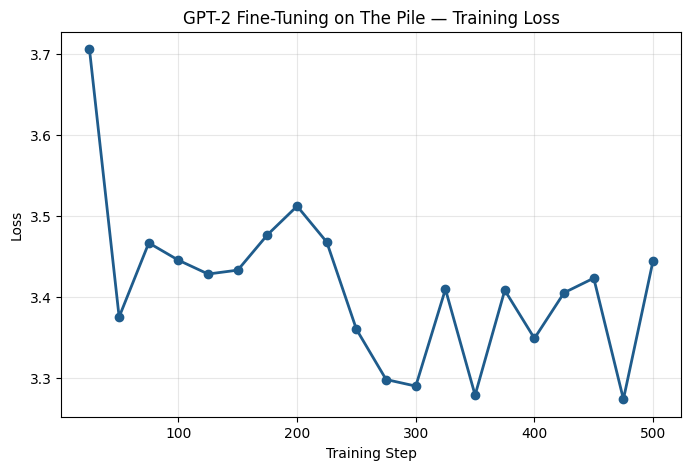

Loss graph saved as training_loss.png


In [ ]:
import matplotlib.pyplot as plt

# I pull the logged loss values out of the trainer's history.
logs = trainer.state.log_history
steps = [x["step"] for x in logs if "loss" in x]
losses = [x["loss"] for x in logs if "loss" in x]

# Plot loss vs. training step.
plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker="o", linewidth=2, color="#1F5C8C")
plt.title("GPT-2 Fine-Tuning on The Pile — Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss graph saved as training_loss.png")

#Interpretation

The graph shows the training loss over 500 steps. It starts high at 3.71, then drops sharply within the first 50 steps as the model quickly adapts to The Pile's text. From there it fluctuates but shows a clear overall downward trend, reaching its lowest points (3.27–3.29) around steps 275–475. The up-and-down "sawtooth" pattern is normal and expected — each point is the loss on a different mini-batch, and because The Pile mixes many text types (web posts, code, papers), some batches are naturally harder to predict than others, causing the wobble. The key evidence of successful learning is that the curve ends lower than it started: the model got measurably better at predicting the text. This is the visual proof that fine-tuning worked.

#Generate text from your fine-tuned model

In [ ]:
def generate_text(prompt, max_new_tokens=100, temperature=0.8, top_k=50, top_p=0.95):
    # Turn the prompt into token IDs and move to the GPU.
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    # Generate a continuation.
    output = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,   # how many new tokens to produce
        temperature=temperature,         # randomness
        top_k=top_k,                     # limit to k most likely words
        top_p=top_p,                     # nucleus sampling
        do_sample=True,                  # sample (don't just pick the top word)
        no_repeat_ngram_size=2,          # avoid repeating the same 2-word phrase
        pad_token_id=tokenizer.eos_token_id,
    )

    # Turn the token IDs back into readable text.
    return tokenizer.decode(output[0], skip_special_tokens=True)

print("generate_text function ready.")

generate_text function ready.


In [ ]:
prompts = [
    "The future of technology is",
    "In recent years, researchers have discovered",
    "Once upon a time",
]

for p in prompts:
    print("=" * 60)
    print("PROMPT:", p)
    print("-" * 60)
    print(generate_text(p))
    print()

PROMPT: The future of technology is
------------------------------------------------------------
The future of technology is not just a story of technological progress. It is a tale of how the future will be better, better and more awesome than ever.

If you're a tech investor in North America, a number of these companies are already doing business there. In 2015 alone, the number one industry in the US is Facebook. A total of $1.6 billion USD in revenues were generated in 2015, according to LinkedIn. This is only the latest in a long-range, but highly successful trend for

PROMPT: In recent years, researchers have discovered
------------------------------------------------------------
In recent years, researchers have discovered a new way to study a variety of pathogens from a wide variety, including a broad range of viruses, bacteria, and fungi, to investigate the role of such viruses in the pathogenesis of diseases. While there are still many unanswered questions about the mechanism

#Interpretation
The fine-tuned model successfully generated coherent, fluent English from all three seed prompts. A few things stand out:

Grammatical fluency — each passage reads as proper English with correct sentence structure, showing the model learned the patterns of the training text.

The Pile's mixed nature shows clearly. Each prompt pulled a different "flavour" from the dataset: the first drifted into tech/business writing (Facebook, revenues, LinkedIn), the second into a scientific/academic register (pathogens, viruses, pathogenesis), and the third into narrative/historical prose (a judge in 1857, New Orleans). This directly reflects that The Pile is a mix of web, academic, and general text — the model absorbed all of it.

Factual accuracy is loose — e.g. "Facebook is the number one industry" and the muddled New Orleans/New York history.

#Content-creation demo

In [ ]:
def content_generator(topic, max_new_tokens=120):
    # I build a prompt that frames the topic as the start of an article.
    prompt = f"{topic}. "
    print("TOPIC:", topic)
    print("=" * 60)
    draft = generate_text(prompt, max_new_tokens=max_new_tokens, temperature=0.9)
    print(draft)
    print("=" * 60)
    return draft

# Demo: generate article intros on a few topics
content_generator("The benefits of learning data analytics")
print()
content_generator("How artificial intelligence is changing marketing")

TOPIC: The benefits of learning data analytics
The benefits of learning data analytics. 
The current version of the Python Data Analysis Toolkit (Python-DataBase) is called the "Python Data Analyzer", and its release is due to the ability to automatically produce an output of data in a way similar to a regular analysis program. In this article we will use these Python-data-analyzer tools to do the analysis of Python data with the help of a real data analysis software.
In the current Python edition of DataBase, the source code for this tool has been downloaded:
    [Python
python-python]
Python code snippets  


TOPIC: How artificial intelligence is changing marketing
How artificial intelligence is changing marketing. 
A new generation of artificialintelligence can help us learn about the world, and its potential.

There are two reasons why artificial intelligent life is so fascinating and fascinating. It is that all the data is in a new place where it is relevant for humans to be able 

'How artificial intelligence is changing marketing. \nA new generation of artificialintelligence can help us learn about the world, and its potential.\n\nThere are two reasons why artificial intelligent life is so fascinating and fascinating. It is that all the data is in a new place where it is relevant for humans to be able to use it to help them understand what it means to do. This is why, for example, artificial brains and artificial life have found new ways to solve problems. The problem is often that we are not familiar with what is important because of what we know to know. Our ability to learn has become more and more complex.'

#Load Qwen2.5-1.5B-Instruct and compare

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# I load a modern instruction-tuned model for comparison.
# Qwen2.5-1.5B-Instruct is ungated (no login needed) and fits on the T4.
qwen_name = "Qwen/Qwen2.5-1.5B-Instruct"

qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_name)
qwen_model = AutoModelForCausalLM.from_pretrained(
    qwen_name,
    torch_dtype=torch.float16,   # half precision to fit memory
    device_map="auto"
)
print("Qwen2.5-1.5B-Instruct loaded.")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2.5-1.5B-Instruct loaded.


In [ ]:
import textwrap

def qwen_generate(user_message, max_new_tokens=200):
    # Instruct models expect a chat format, not raw text.
    messages = [{"role": "user", "content": user_message}]

    # Apply chat template to get a BatchEncoding object (dictionary-like) with tensors
    encoded_input = qwen_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    )
    # Move the tensors within the BatchEncoding object to the model's device
    encoded_input = encoded_input.to(qwen_model.device)

    output = qwen_model.generate(
        **encoded_input,  # This will unpack into input_ids=tensor, attention_mask=tensor
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=qwen_tokenizer.eos_token_id,
    )
    # Decode only the newly generated part (skip the prompt).
    # Use the shape of the original input_ids tensor for slicing
    reply = qwen_tokenizer.decode(output[0][encoded_input['input_ids'].shape[-1]:], skip_special_tokens=True)
    return textwrap.fill(reply, width=90)

# Same topics as my GPT-2 demo, for a fair comparison
print("QWEN OUTPUT 1")
print("=" * 60)
print(qwen_generate("Write a short intro about the benefits of learning data analytics."))
print("\n" + "=" * 60)
print("QWEN OUTPUT 2")
print("=" * 60)
print(qwen_generate("Write a short intro about how artificial intelligence is changing marketing."))

QWEN OUTPUT 1
Learning data analytics offers numerous benefits that can enhance your career prospects
and provide valuable insights into decision-making processes. Here are some key
advantages:  1. **Enhanced Problem-Solving Skills**: Data analytics training equips you
with advanced problem-solving skills to analyze complex datasets efficiently.  2.
**Increased Job Opportunities**: A strong foundation in data analytics opens doors to
roles across various industries such as finance, healthcare, technology, and more.  3.
**Improved Decision Making**: By leveraging data analytics tools and techniques,
professionals can make informed decisions based on real-world data rather than assumptions
or intuition.  4. **Competitive Advantage**: In today's data-driven world, having
expertise in data analytics gives individuals and companies a competitive edge over those
without this skill set.  5. **Continuous Learning**: The field of data analytics is
constantly evolving, making it an excellent are

###Interpretation
Running the same topics through Qwen2.5-1.5B-Instruct — a modern instruction-tuned model — produced dramatically more coherent, structured, and factual output than my fine-tuned GPT-2.

In [ ]:
   model.save_pretrained("./gpt2-pile-final")
   tokenizer.save_pretrained("./gpt2-pile-final")
   print("Saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved.
